# SVM - Part 1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from cvxopt import matrix, solvers
import matplotlib.pyplot as plt
import time 
from SVM import *


In [2]:
df = pd.read_csv('dataset/GENDER_CLASSIFICATION.csv')
df.head()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,gt
0,-0.900846,0.102587,-0.397814,0.112796,2.588096,-0.192754,-0.968311,-0.490886,-0.872099,-0.288411,...,2.541431,1.739102,0.166066,4.584869,-0.107031,-0.913990,-0.686416,-0.368085,-0.870545,0
1,-0.838868,0.039976,-0.387101,0.055413,2.066874,-0.226948,-0.947416,-0.472817,-0.855387,-0.207101,...,1.991721,1.259745,0.065058,3.019790,-0.110633,-0.890023,-0.611625,-0.298235,-0.855208,0
2,-0.814961,-0.010184,-0.397147,0.092713,1.897454,-0.269387,-0.945285,-0.449579,-0.849705,-0.151179,...,1.822978,1.105511,0.065353,2.500681,-0.052730,-0.885691,-0.583346,-0.218140,-0.856456,0
3,-0.110470,0.027849,-0.044310,-0.005343,0.177831,-0.232092,-0.562700,-0.400713,-0.552356,0.037349,...,-0.098367,-0.370318,-0.123008,-0.861314,0.106840,-0.483669,-0.224164,0.147321,-0.615051,0
4,-0.626313,-0.091985,-0.373756,-0.005083,1.172486,-0.314868,-0.885046,-0.412587,-0.818729,-0.012022,...,1.030348,0.421886,-0.068029,0.258984,-0.057158,-0.834079,-0.441066,-0.099874,-0.829539,0


# Fit SMO Opt

In [19]:
# Example usage classic fit:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values

# Train/val split (80/20)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVM(C=1.0, kernel='Gaussian', gamma=0.5)

time_start = time.time()
model.fit(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")
# ----- 4. Evaluation -----
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Accuracy on training set:", train_acc)
print("Accuracy on test set:", test_acc)

     pcost       dcost       gap    pres   dres
 0: -1.7863e+02 -1.7813e+03  9e+03  3e+00  1e-15
 1: -1.0780e+02 -1.0270e+03  1e+03  1e-01  1e-15
 2: -1.2223e+02 -2.6517e+02  2e+02  1e-02  1e-15
 3: -1.3459e+02 -1.7026e+02  4e+01  2e-03  8e-16
 4: -1.3798e+02 -1.4939e+02  1e+01  4e-04  7e-16
 5: -1.3960e+02 -1.4311e+02  4e+00  2e-15  8e-16
 6: -1.4018e+02 -1.4136e+02  1e+00  3e-15  9e-16
 7: -1.4041e+02 -1.4084e+02  4e-01  4e-15  8e-16
 8: -1.4053e+02 -1.4059e+02  6e-02  1e-15  8e-16
 9: -1.4055e+02 -1.4056e+02  6e-03  7e-15  8e-16
10: -1.4055e+02 -1.4055e+02  2e-04  5e-15  9e-16
11: -1.4055e+02 -1.4055e+02  3e-06  3e-15  9e-16
Optimal solution found.
Training time: 0.5132899284362793 seconds
Accuracy on training set: 0.92
Accuracy on test set: 0.91


In [15]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C = list(np.arange(0.05, 5, 0.25))
gamma_grid = list(np.linspace(0.1, 10, 20))
degree_grid = [2, 3, 5, 10]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid=C,  
    gamma_grid=gamma_grid,
    degree_grid=degree_grid,
    k=5
)


print("Best:", best_params, "score:", best_score)

# 3) final fit with best hyperparams
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit(X_train, y_train)

# 4) test 
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)





{'C': 0.8, 'gamma': 3.747368421052632, 'kernel': 'Gaussian'} 0.9212499999999999
Best: {'C': 0.8, 'gamma': 3.747368421052632, 'kernel': 'Gaussian'} score: 0.9212499999999999


In [20]:
model = SVM(C=0.8, kernel='Gaussian', gamma=3.747368421052632)
time_start = time.time()
model.fit(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")

y_pred = model.predict(X_test)
X_pred = model.predict(X_train)

     pcost       dcost       gap    pres   dres
 0: -1.4684e+02 -1.4121e+03  8e+03  3e+00  7e-16
 1: -9.6679e+01 -9.4239e+02  1e+03  8e-02  6e-16
 2: -1.1617e+02 -2.2467e+02  1e+02  9e-03  5e-16
 3: -1.2806e+02 -1.5569e+02  3e+01  2e-03  3e-16
 4: -1.3212e+02 -1.3899e+02  7e+00  2e-04  3e-16
 5: -1.3349e+02 -1.3492e+02  1e+00  1e-05  3e-16
 6: -1.3381e+02 -1.3411e+02  3e-01  1e-07  3e-16
 7: -1.3388e+02 -1.3392e+02  3e-02  1e-08  3e-16
 8: -1.3389e+02 -1.3390e+02  2e-03  2e-10  3e-16
 9: -1.3389e+02 -1.3389e+02  5e-05  4e-12  3e-16
Optimal solution found.
Training time: 0.48076367378234863 seconds


In [16]:
print(classification_report(y_train, X_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       404
           1       0.96      0.95      0.95       396

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [17]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.95      0.91        96
           1       0.95      0.87      0.90       104

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



C:\Users\User\AppData\Local\Temp\ipykernel_19028\3647372425.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


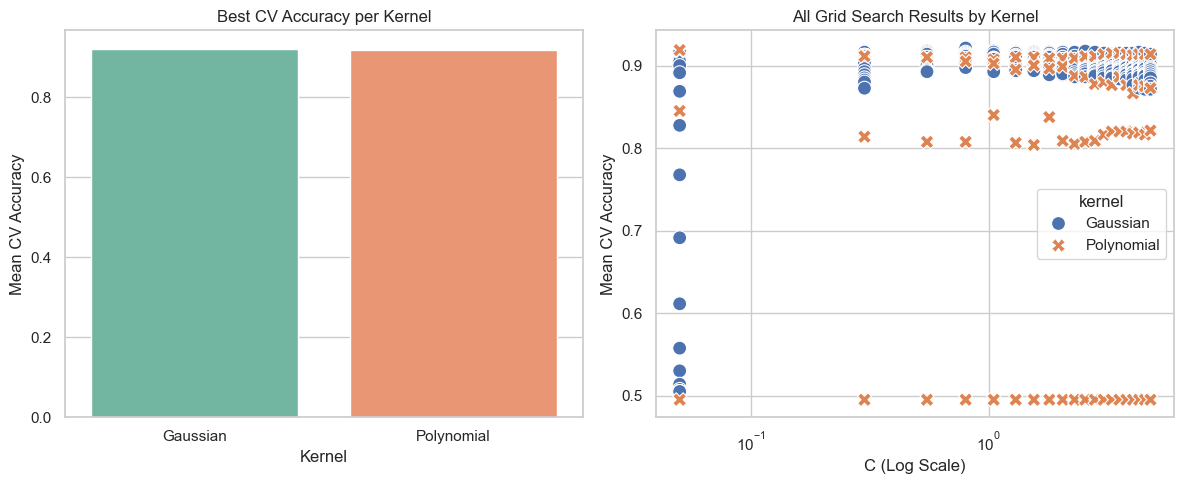

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. General comparson of best scores per kernel
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot for all results 
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


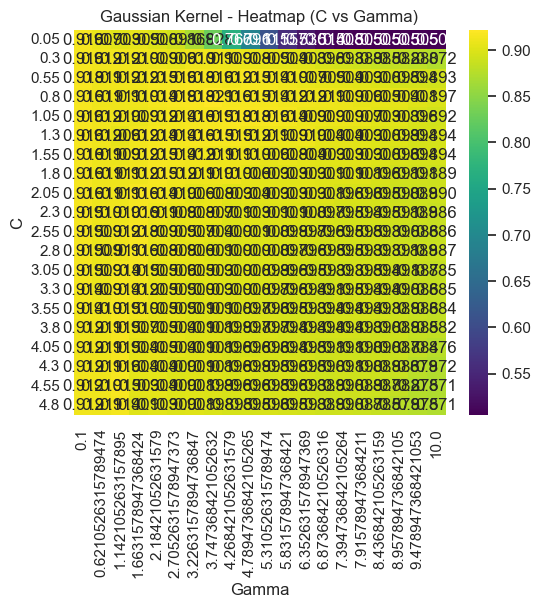

In [19]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


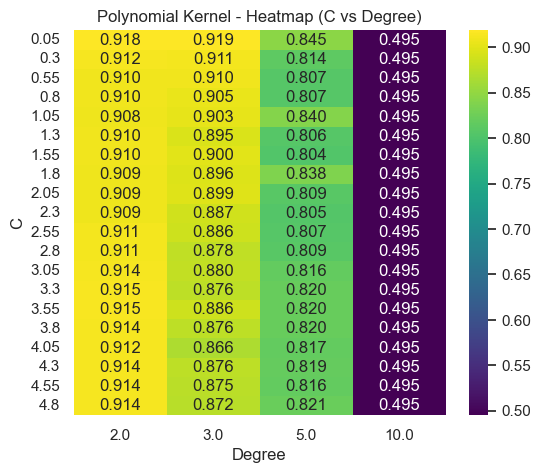

In [20]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [21]:
poly_df['C'] = round(poly_df['C'],2).astype(str)
gaussian_df['C'] = round(gaussian_df['C'],2).astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_19028\2857440888.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = round(poly_df['C'],2).astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_19028\2857440888.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = round(gaussian_df['C'],2).astype(str)


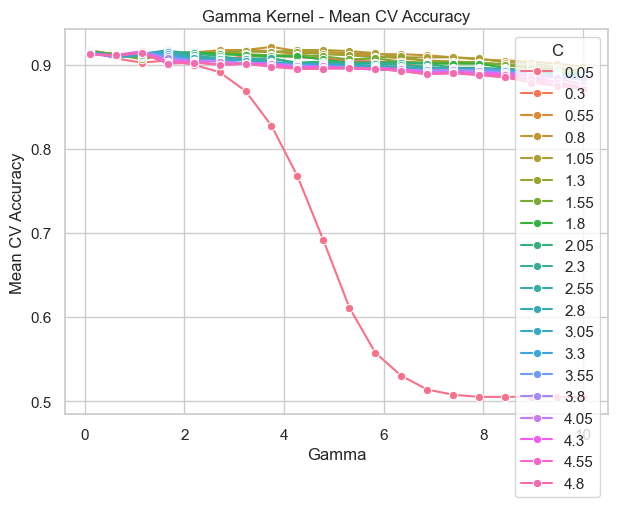

In [90]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

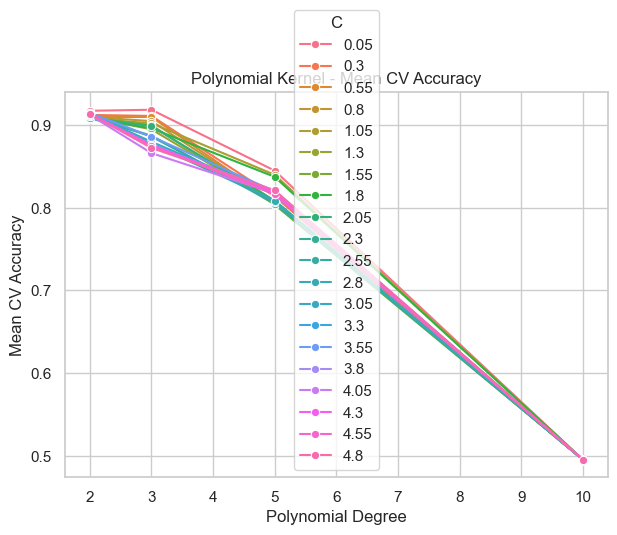

In [89]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


# Part 2

In [24]:
# Example usage smo fit:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values

# Train/val split (80/20)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVM(C=0.1, kernel='Gaussian', gamma=3)

model.fit_smo(X_train, y_train, verbose=True)

# ----- 4. Evaluation -----
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Accuracy on training set:", train_acc)
print("Accuracy on test set:", test_acc)

Iteration 1, num_changed = 70, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_changed = 0, passes = 1
Iteration 4, num_changed = 0, passes = 2
Iteration 5, num_changed = 0, passes = 3
Iteration 6, num_changed = 0, passes = 4
Iteration 7, num_changed = 0, passes = 5
Iteration 8, num_changed = 0, passes = 6
Iteration 9, num_changed = 0, passes = 7
Iteration 10, num_changed = 0, passes = 8
Iteration 11, num_changed = 0, passes = 9
Iteration 12, num_changed = 0, passes = 10
Iteration 13, num_changed = 0, passes = 11
Iteration 14, num_changed = 0, passes = 12
Iteration 15, num_changed = 0, passes = 13
Iteration 16, num_changed = 0, passes = 14
Iteration 17, num_changed = 0, passes = 15
Iteration 18, num_changed = 0, passes = 16
Iteration 19, num_changed = 0, passes = 17
Iteration 20, num_changed = 0, passes = 18
Iteration 21, num_changed = 0, passes = 19
SMO finished in 21 iterations. Support vectors: 140
Accuracy on training set: 0.9125
Accuracy on test set: 0.9


In [14]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C_grid = list(np.arange(0.05, 5, 0.25))
gamma_grid = list(np.linspace(0.1, 10, 20))
degree_grid = [2, 3, 4, 5]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid, gamma_grid=gamma_grid, degree_grid=degree_grid, k=5, smo=True
)


print("Best:", best_params, "score:", best_score)

# 3) final fit with best hyperparams
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit_smo(X_train, y_train)

# 4) test 
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)

print(classification_report(y_train, X_pred))
print(classification_report(y_test, y_pred))

Trying C=0.05, gamma=0.1 -> mean score=0.9175
Trying C=0.05, gamma=0.6210526315789474 -> mean score=0.9137
Trying C=0.05, gamma=1.142105263157895 -> mean score=0.9100
Trying C=0.05, gamma=1.6631578947368424 -> mean score=0.9038
Trying C=0.05, gamma=2.18421052631579 -> mean score=0.9075
Trying C=0.05, gamma=2.7052631578947373 -> mean score=0.9000
Trying C=0.05, gamma=3.2263157894736847 -> mean score=0.9025
Trying C=0.05, gamma=3.747368421052632 -> mean score=0.9012
Trying C=0.05, gamma=4.268421052631579 -> mean score=0.9050
Trying C=0.05, gamma=4.7894736842105265 -> mean score=0.8975
Trying C=0.05, gamma=5.310526315789474 -> mean score=0.8900
Trying C=0.05, gamma=5.831578947368421 -> mean score=0.9075
Trying C=0.05, gamma=6.352631578947369 -> mean score=0.9075
Trying C=0.05, gamma=6.873684210526316 -> mean score=0.9037
Trying C=0.05, gamma=7.394736842105264 -> mean score=0.9012
Trying C=0.05, gamma=7.915789473684211 -> mean score=0.8988
Trying C=0.05, gamma=8.436842105263159 -> mean sco

In [21]:
model = SVM(C=0.05, kernel='Gaussian', gamma=0.1)
time_start = time.time()
model.fit_smo(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")

y_pred = model.predict(X_test)
X_pred = model.predict(X_train)

print(classification_report(y_train, X_pred))
print(classification_report(y_test, y_pred))

Iteration 1, num_changed = 54, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_changed = 0, passes = 1
Iteration 4, num_changed = 0, passes = 2
Iteration 5, num_changed = 0, passes = 3
Iteration 6, num_changed = 0, passes = 4
Iteration 7, num_changed = 0, passes = 5
Iteration 8, num_changed = 0, passes = 6
Iteration 9, num_changed = 0, passes = 7
Iteration 10, num_changed = 0, passes = 8
Iteration 11, num_changed = 0, passes = 9
Iteration 12, num_changed = 0, passes = 10
Iteration 13, num_changed = 0, passes = 11
Iteration 14, num_changed = 0, passes = 12
Iteration 15, num_changed = 0, passes = 13
Iteration 16, num_changed = 0, passes = 14
Iteration 17, num_changed = 0, passes = 15
Iteration 18, num_changed = 0, passes = 16
Iteration 19, num_changed = 0, passes = 17
Iteration 20, num_changed = 0, passes = 18
Iteration 21, num_changed = 0, passes = 19
SMO finished in 21 iterations. Support vectors: 108
Training time: 0.5579726696014404 seconds
              precisio

C:\Users\User\AppData\Local\Temp\ipykernel_19028\3647372425.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


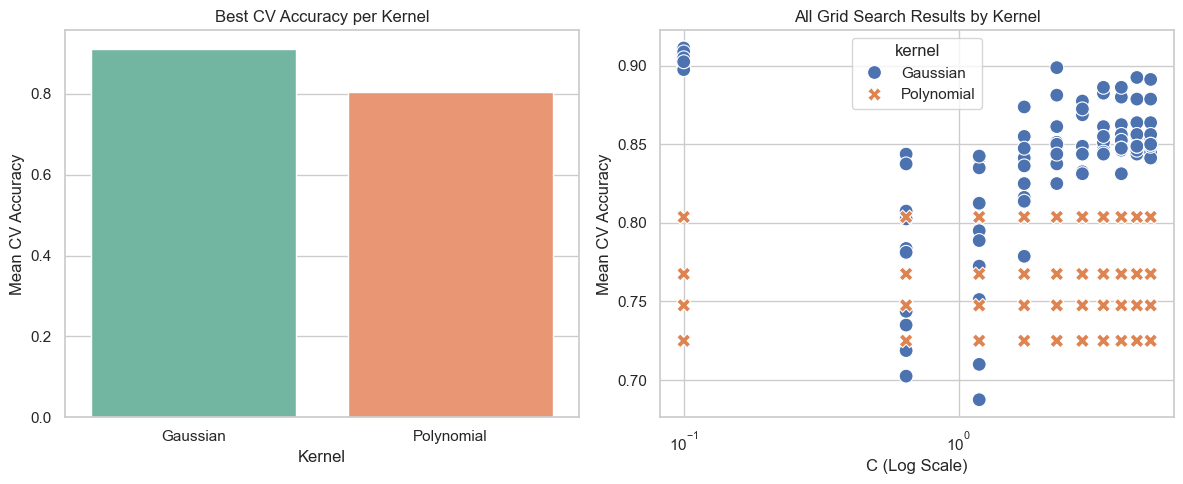

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. General comparson of best scores per kernel
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot for all results 
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


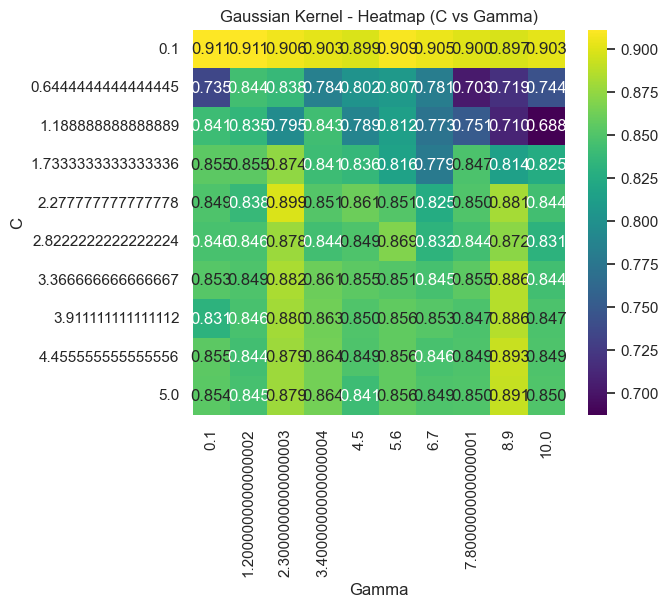

In [8]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


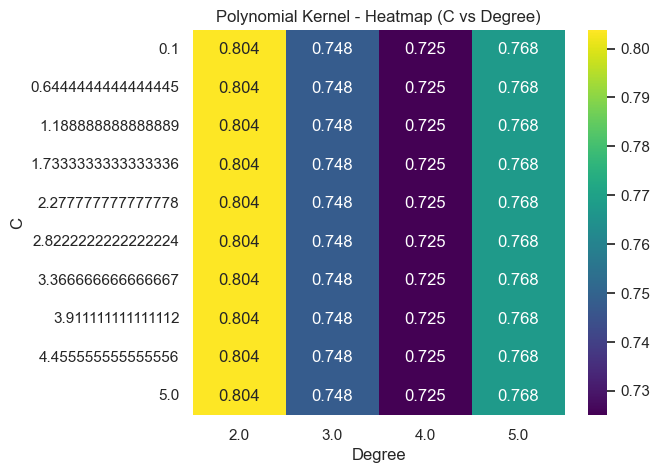

In [9]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [10]:
poly_df['C'] = round(poly_df['C'], 2).astype(str)
gaussian_df['C'] = round(gaussian_df['C'], 2).astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_19028\2749937874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = round(poly_df['C'], 2).astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_19028\2749937874.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = round(gaussian_df['C'], 2).astype(str)


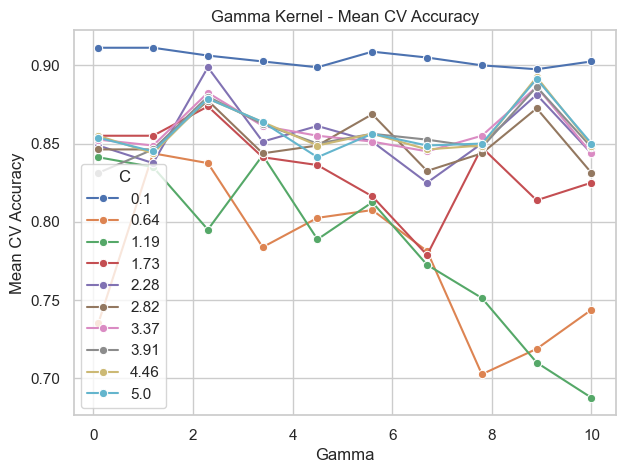

In [11]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

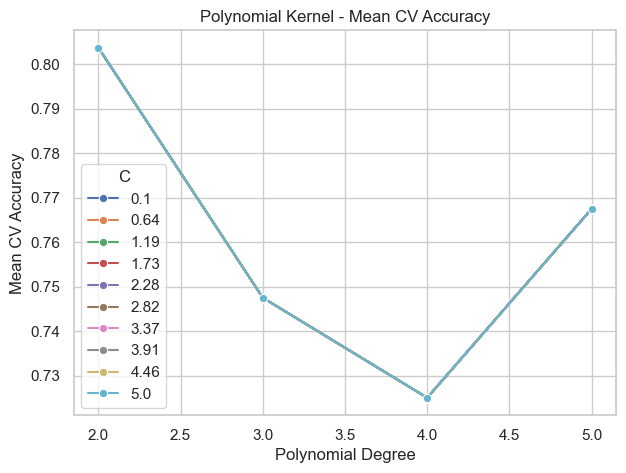

In [12]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


# Bonus Part - Ethnicity Classification

In [12]:
df_2 = pd.read_csv("dataset/ETHNICITY_CLASSIFICATION.csv")

In [22]:
df_2.head()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,gt
0,0.502792,-0.349373,-0.068018,-0.627533,0.130331,0.373488,-0.491088,0.416753,-0.046255,0.325566,...,0.374539,-0.605601,0.579226,-0.119241,0.185425,-0.255194,0.705415,-0.027761,0.581276,0
1,0.741646,-0.240194,-0.006548,-0.639129,-0.059524,0.457087,-0.500733,0.345128,-0.040395,0.334946,...,0.353851,-0.651629,0.129014,-0.034723,0.392575,-0.289928,0.380891,-0.157109,0.742231,0
2,2.836617,1.256781,2.227900,-0.603728,0.200403,1.366685,-0.666864,1.156750,-0.004516,0.767839,...,0.265453,-0.762246,-0.331476,0.051758,1.255034,-0.529064,1.412283,1.182029,3.046791,0
3,2.576996,1.784919,3.166102,-0.539903,0.108954,1.773622,-0.708488,2.679638,-0.313469,1.817676,...,0.295006,-0.866968,2.203584,-0.428082,-0.368396,-0.398743,4.043780,2.281445,5.065996,0
4,1.614504,1.103544,0.755605,-0.561434,-0.551708,0.936586,-0.575693,0.533321,0.033991,0.980126,...,0.155448,-0.825574,-0.627675,0.060466,0.815617,-0.434781,0.040881,-0.152861,2.191638,0


<Axes: xlabel='gt'>

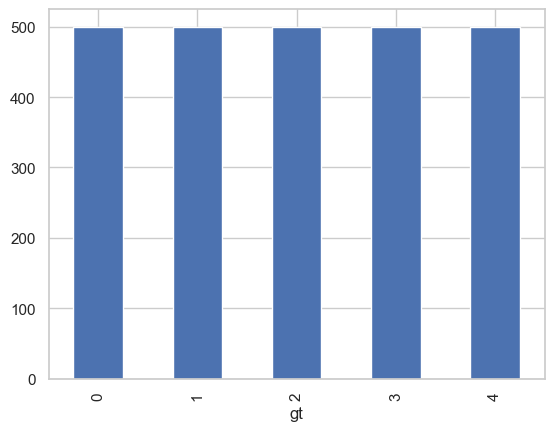

In [27]:
df_2['gt'].value_counts().plot(kind='bar') #balanced classes

In [13]:
from itertools import combinations

unique_values = df_2['gt'].unique()
possible_combinations = list(combinations(unique_values, 3))
possible_combinations = [tuple(int(x) for x in combo) for combo in combinations(unique_values, 3)]


for combo in possible_combinations:
    print(combo)

(0, 1, 2)
(0, 1, 3)
(0, 1, 4)
(0, 2, 3)
(0, 2, 4)
(0, 3, 4)
(1, 2, 3)
(1, 2, 4)
(1, 3, 4)
(2, 3, 4)


In [52]:
from itertools import combinations
from sklearn.metrics import classification_report
from collections import defaultdict

results_ovr_classic_fit = []

C_list = [0.01, 0.05]
gamma_list = [0.5, 0.75]

all_results_1 = defaultdict(list)

for C in C_list:
    for gamma in gamma_list:
        print(f"Trying C={C}, gamma={gamma}")
        for comb in possible_combinations:
            print(f"Training on classes: {comb}")
            selected_classes = comb  
            df_temp = df_2[df_2['gt'].isin(selected_classes)]

            X = df_temp.drop('gt', axis=1).values
            y = df_temp['gt'].values

            from sklearn.model_selection import train_test_split
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            multi_svm = MultiSVM(C=C, kernel='Gaussian', gamma=gamma, method='OvR')
            multi_svm.fit(X_train, y_train)
            y_pred = multi_svm.predict(X_test)

            # Store detailed results
            report = classification_report(y_test, y_pred, output_dict=True)
            acc = report['accuracy']  # Accuracy is a float
            all_results_1[(C, gamma)].append(acc)  # Only group by C and gamma

            # Store full results if needed later
            results_ovr_classic_fit.append({
                'C': C,
                'gamma': gamma,
                'classes': comb,
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'y_pred': y_pred,
                'report': report
            })

            print(classification_report(y_test, y_pred))


Trying C=0.01, gamma=0.5
Training on classes: (0, 1, 2)
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       104
           1       0.87      0.90      0.88        86
           2       0.90      0.88      0.89       110

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

Training on classes: (0, 1, 3)
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       104
           1       0.81      0.86      0.84        86
           3       0.89      0.84      0.86       110

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Training on classes: (0, 1, 4)
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       104
           

In [53]:
averages = {key: sum(vals) / len(vals) for key, vals in all_results_1.items()}

# Output 
for key, avg in sorted(averages.items()):
    print(f"{key}: {avg:.4f}")


(0.01, 0.5): 0.8200
(0.01, 0.75): 0.8170
(0.05, 0.5): 0.8207
(0.05, 0.75): 0.8163


In [26]:
multi_svm = MultiSVM(C=0.05, kernel='Gaussian', gamma=0.5, method='OvR')

time_start = time.time()
multi_svm.fit(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")

     pcost       dcost       gap    pres   dres
 0: -1.0119e+02 -9.2169e+01  6e+03  6e+01  7e-16
 1: -1.6453e+01 -8.7973e+01  3e+02  2e+00  8e-16
 2: -1.2590e+01 -5.0391e+01  4e+01  3e-16  6e-16
 3: -1.3664e+01 -1.8356e+01  5e+00  2e-16  5e-16
 4: -1.4168e+01 -1.5586e+01  1e+00  1e-16  3e-16
 5: -1.4385e+01 -1.4984e+01  6e-01  2e-16  3e-16
 6: -1.4486e+01 -1.4775e+01  3e-01  2e-16  2e-16
 7: -1.4556e+01 -1.4643e+01  9e-02  2e-16  3e-16
 8: -1.4579e+01 -1.4607e+01  3e-02  2e-16  3e-16
 9: -1.4588e+01 -1.4593e+01  5e-03  2e-16  3e-16
10: -1.4590e+01 -1.4591e+01  3e-04  3e-16  3e-16
11: -1.4591e+01 -1.4591e+01  7e-06  2e-16  4e-16
Optimal solution found.
Training time: 0.8434886932373047 seconds


In [54]:
C_target = 0.05
gamma_target = 0.5

for res in results_ovr_classic_fit:
    if res['C'] == C_target and res['gamma'] == gamma_target:
        print("C:", res['C'])
        print("Gamma:", res['gamma'])
        print("Classi:", res['classes'])
        print("Accuracy:", res['report']['accuracy'])
        print("-" * 40)


C: 0.05
Gamma: 0.5
Classi: (0, 1, 2)
Accuracy: 0.8733333333333333
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 1, 3)
Accuracy: 0.8533333333333334
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 1, 4)
Accuracy: 0.7733333333333333
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 2, 3)
Accuracy: 0.8633333333333333
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 2, 4)
Accuracy: 0.7933333333333333
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 3, 4)
Accuracy: 0.7166666666666667
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (1, 2, 3)
Accuracy: 0.9033333333333333
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (1, 2, 4)
Accuracy: 0.8566666666666667
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (1, 3, 4)
Accuracy: 0.7933333333333333
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (2, 3, 4)


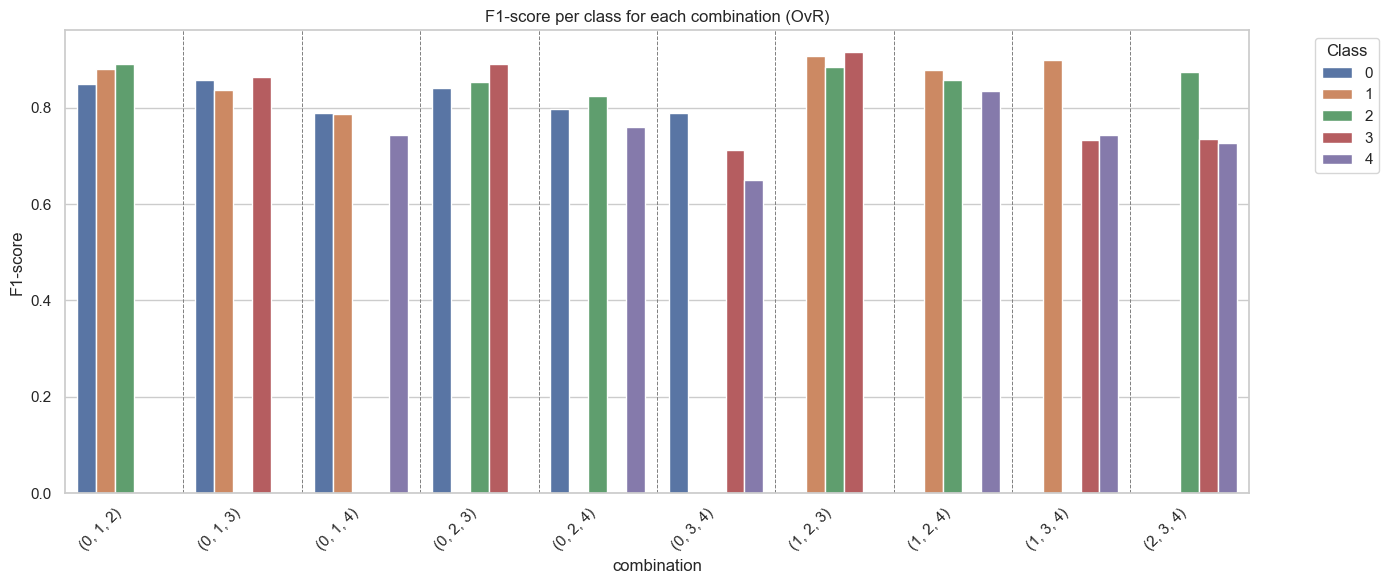

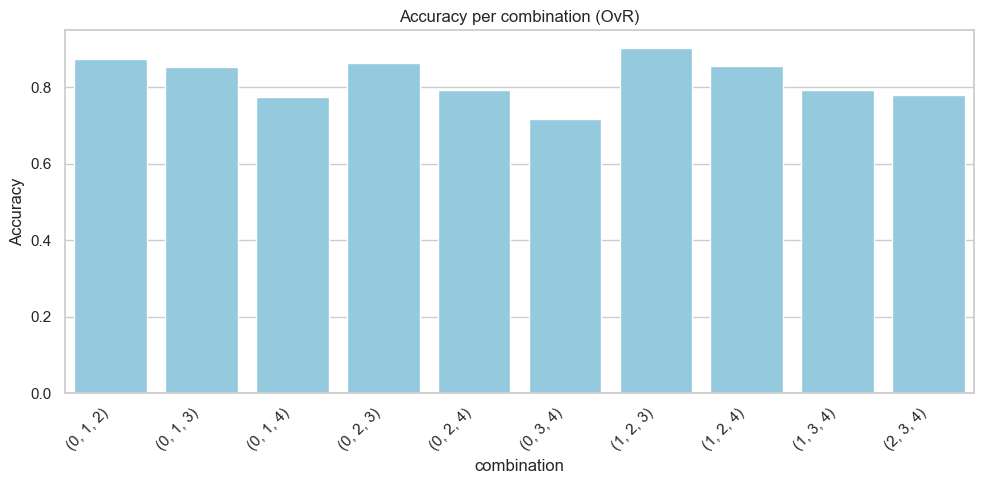

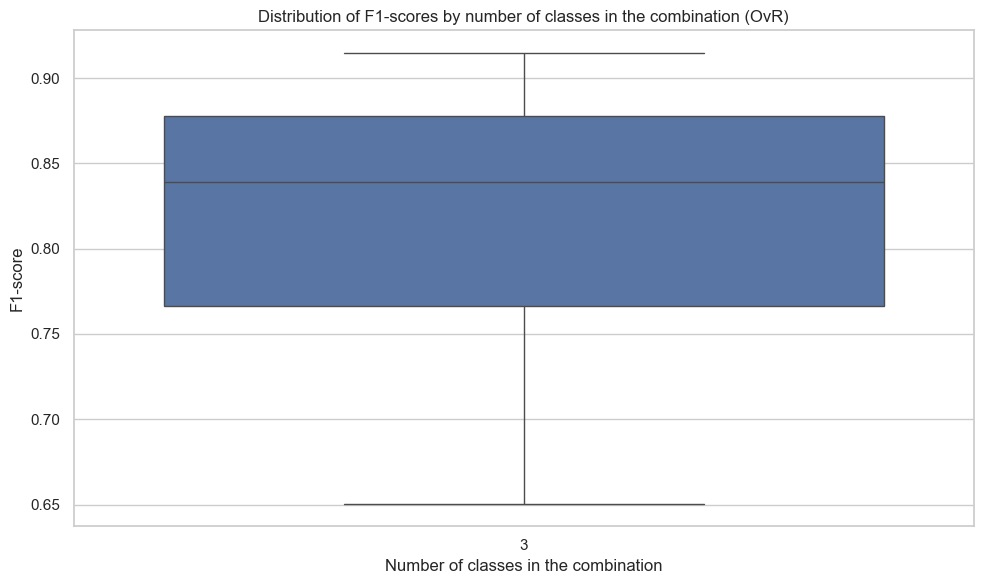

=== OvR PERFORMANCE SUMMARY ===

1. Average performance by number of classes:
             mean       std  count
n_classes                         
3          0.8202  0.068778     30

2. Best combinations by F1-score:
combination  f1-score
  (1, 2, 3)  0.903333
  (0, 1, 2)  0.873333
  (0, 2, 3)  0.863333
  (1, 2, 4)  0.856667
  (0, 1, 3)  0.853333

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.716667
  (0, 1, 4)  0.773333
  (2, 3, 4)  0.780000
  (0, 2, 4)  0.793333
  (1, 3, 4)  0.793333


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

C_target = 0.05
gamma_target = 0.5


plot_data = []

for result in results_ovr_classic_fit:
    if result['C'] != C_target or result['gamma'] != gamma_target:
        continue  # salta le combinazioni non desiderate

    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb),
            'C': result['C'],
            'gamma': result['gamma']
        })
    
    # Add overall accuracy as a separate entry
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb),
        'C': result['C'],
        'gamma': result['gamma']
    })

# Create DataFrame for plotting
df_plot = pd.DataFrame(plot_data)


# ----------- F1-SCORE PER CLASS -----------

plt.figure(figsize=(14, 6))

# Filter out the overall accuracy rows
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvR)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# ➖ Dividing lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION -----------

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot[df_plot['class'] == 'overall'],
           x='combination', y='f1-score', color='skyblue')
plt.title("Accuracy per combination (OvR)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of F1-scores grouped by number of classes in the combination
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("Distribution of F1-scores by number of classes in the combination (OvR)")
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== OvR PERFORMANCE SUMMARY ===")
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


In [56]:
from itertools import combinations
from sklearn.metrics import classification_report
from collections import defaultdict

results_ovr_smo_fit = []

C_list = [0.01, 0.05]
gamma_list = [0.5, 0.75]

all_results_2 = defaultdict(list)

for C in C_list:
    for gamma in gamma_list:
        print(f"Trying C={C}, gamma={gamma}")
        for comb in possible_combinations:
            print(f"Training on classes: {comb}")
            selected_classes = comb  
            df_temp = df_2[df_2['gt'].isin(selected_classes)]

            X = df_temp.drop('gt', axis=1).values
            y = df_temp['gt'].values

            from sklearn.model_selection import train_test_split
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            multi_svm = MultiSVM(C=C, kernel='Gaussian', gamma = gamma, method='OvR')
            multi_svm.fit_smo(X_train, y_train)
            y_pred = multi_svm.predict(X_test)

            # Store detailed results
            report = classification_report(y_test, y_pred, output_dict=True)
            acc = report['accuracy']  # Accuracy is a float
            all_results_2[(C, gamma)].append(acc)  # Only group by C and gamma

            # Store full results if needed later
            results_ovr_smo_fit.append({
                'C': C,
                'gamma': gamma,
                'classes': comb,
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'y_pred': y_pred,
                'report': report
            })

            print(classification_report(y_test, y_pred))


Trying C=0.01, gamma=0.5
Training on classes: (0, 1, 2)
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       104
           1       0.88      0.91      0.89        86
           2       0.92      0.90      0.91       110

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

Training on classes: (0, 1, 3)
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       104
           1       0.84      0.84      0.84        86
           3       0.88      0.84      0.86       110

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Training on classes: (0, 1, 4)
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       104
           

In [57]:
averages = {key: sum(vals) / len(vals) for key, vals in all_results_2.items()}

# Output 
for key, avg in sorted(averages.items()):
    print(f"{key}: {avg:.4f}")

(0.01, 0.5): 0.8167
(0.01, 0.75): 0.8167
(0.05, 0.5): 0.8167
(0.05, 0.75): 0.8167


In [27]:
multi_svm = MultiSVM(C=0.05, kernel='Gaussian', gamma=0.5, method='OvR')
time_start = time.time()
multi_svm.fit_smo(X_train, y_train, verbose=True) 
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")

Iteration 1, num_changed = 54, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_changed = 0, passes = 1
Iteration 4, num_changed = 0, passes = 2
Iteration 5, num_changed = 0, passes = 3
Iteration 6, num_changed = 0, passes = 4
Iteration 7, num_changed = 0, passes = 5
Iteration 8, num_changed = 0, passes = 6
Iteration 9, num_changed = 0, passes = 7
Iteration 10, num_changed = 0, passes = 8
SMO finished in 10 iterations. Support vectors: 108
Training time: 0.4024364948272705 seconds


In [58]:
C_target = 0.05
gamma_target = 0.5

for res in results_ovr_smo_fit:
    if res['C'] == C_target and res['gamma'] == gamma_target:
        print("C:", res['C'])
        print("Gamma:", res['gamma'])
        print("Classi:", res['classes'])
        print("Accuracy:", res['report']['accuracy'])
        print("-" * 40)


C: 0.05
Gamma: 0.5
Classi: (0, 1, 2)
Accuracy: 0.8833333333333333
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 1, 3)
Accuracy: 0.85
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 1, 4)
Accuracy: 0.8
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 2, 3)
Accuracy: 0.8533333333333334
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 2, 4)
Accuracy: 0.8
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (0, 3, 4)
Accuracy: 0.6933333333333334
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (1, 2, 3)
Accuracy: 0.8966666666666666
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (1, 2, 4)
Accuracy: 0.8666666666666667
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (1, 3, 4)
Accuracy: 0.76
----------------------------------------
C: 0.05
Gamma: 0.5
Classi: (2, 3, 4)
Accuracy: 0.7633333333333333
-----------------------------

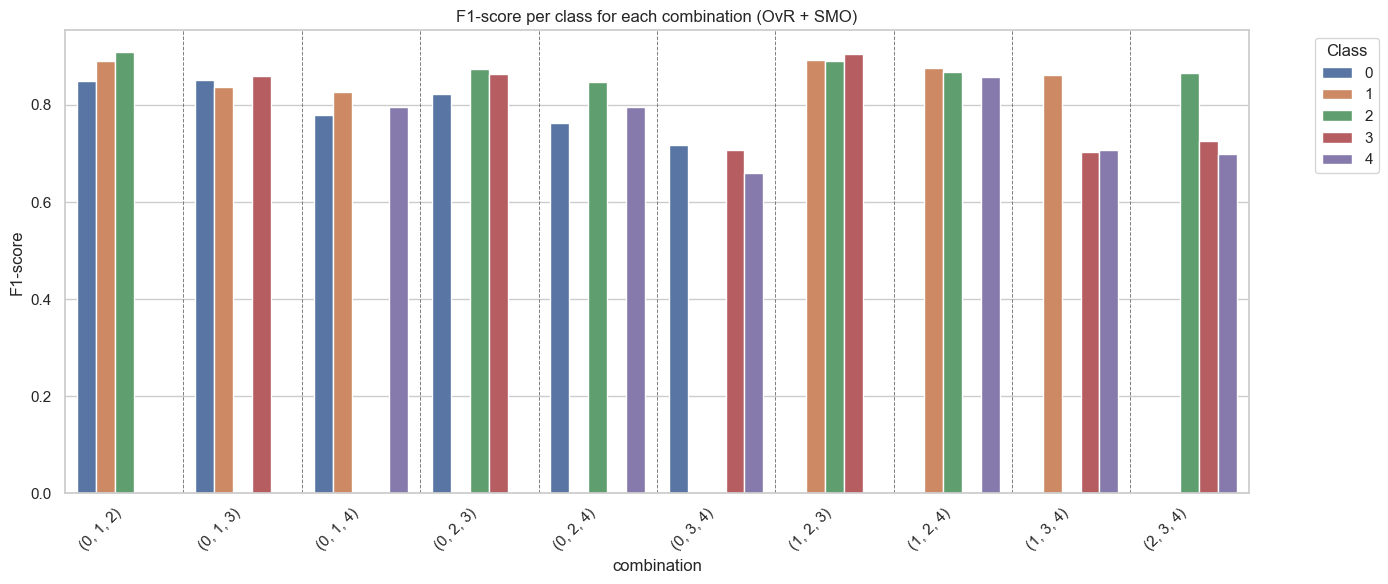

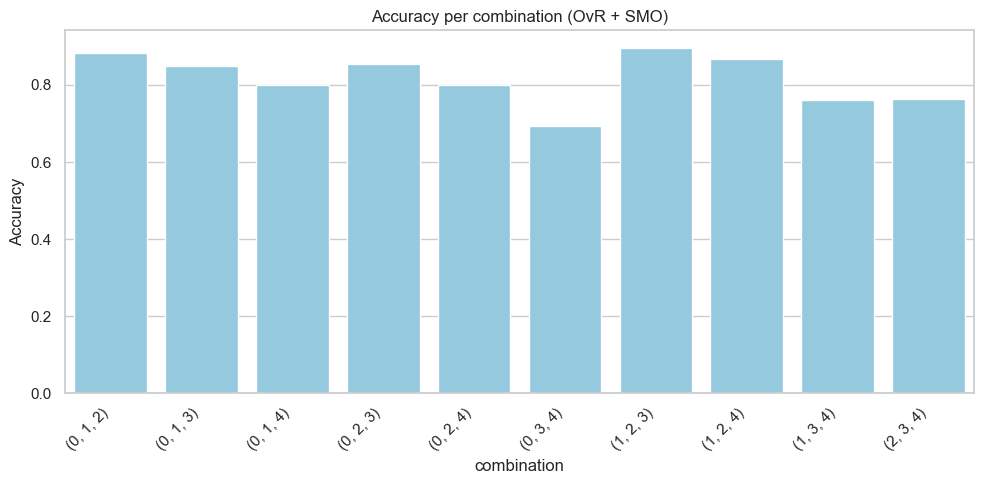

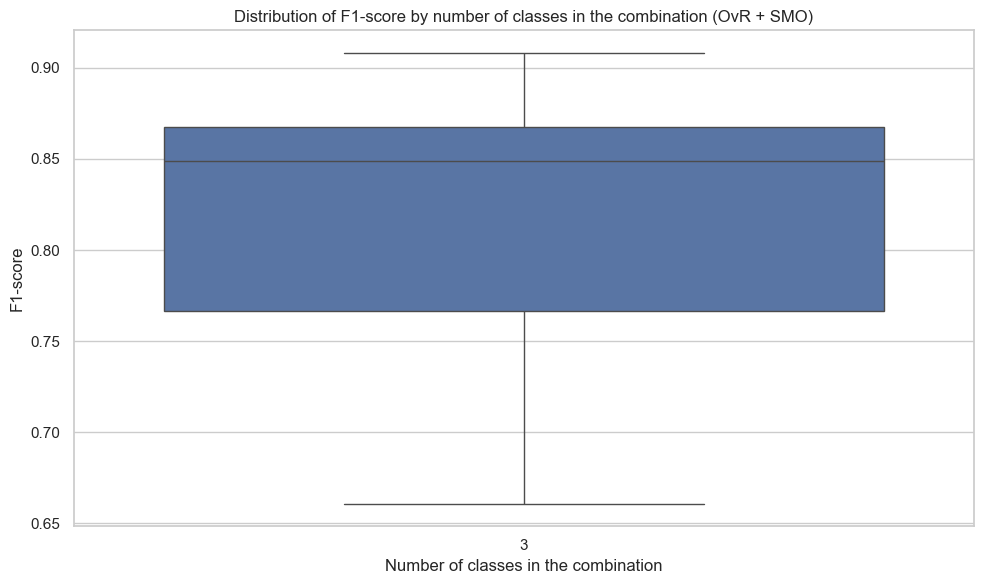

=== OvR + SMO PERFORMANCE SUMMARY ===

1. Average performance by number of classes:
               mean       std  count
n_classes                           
3          0.816837  0.073034     30

2. Best combinations by F1-score:
combination  f1-score
  (1, 2, 3)  0.896667
  (0, 1, 2)  0.883333
  (1, 2, 4)  0.866667
  (0, 2, 3)  0.853333
  (0, 1, 3)  0.850000

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.693333
  (1, 3, 4)  0.760000
  (2, 3, 4)  0.763333
  (0, 1, 4)  0.800000
  (0, 2, 4)  0.800000


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

C_target = 0.05
gamma_target = 0.5


plot_data = []

for result in results_ovr_smo_fit:
    if result['C'] != C_target or result['gamma'] != gamma_target:
        continue  # salta le combinazioni non desiderate

    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb),
            'C': result['C'],
            'gamma': result['gamma']
        })
    
    # Add overall accuracy as a separate entry
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb),
        'C': result['C'],
        'gamma': result['gamma']
    })

# Create DataFrame for plotting
df_plot = pd.DataFrame(plot_data)

# ----------- F1-SCORE PER CLASS PLOT -----------

plt.figure(figsize=(14, 6))

# Filter the data to exclude 'overall'
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvR + SMO)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Divider lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION PLOT -----------

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot[df_plot['class'] == 'overall'],
           x='combination', y='f1-score', color='skyblue')
plt.title("Accuracy per combination (OvR + SMO)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of performances grouped by number of classes
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("Distribution of F1-score by number of classes in the combination (OvR + SMO)")  
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== OvR + SMO PERFORMANCE SUMMARY ===")  
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


In [15]:
from itertools import combinations
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from collections import defaultdict

results_ovo_classic_fit = []
all_results_3 = defaultdict(list)




for comb in possible_combinations:
    print(f"Training on classes: {comb}")
    selected_classes = comb  
    df_temp = df_2[df_2['gt'].isin(selected_classes)]

    X = df_temp.drop('gt', axis=1).values
    y = df_temp['gt'].values

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

    # Train Multi-class SVM (OvO)
    multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5, method='OvO')
    multi_svm.fit(X_train, y_train)
    y_pred = multi_svm.predict(X_test)

    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    acc = report['accuracy']
    all_results_3[(1.0, 0.5)].append(acc)

    # Store full result for future use
    results_ovo_classic_fit.append({
        'C': 1.0,
        'gamma': 0.5,                
        'classes': comb,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'report': report
    })

    # Print report
    print(classification_report(y_test, y_pred))


Training on classes: (0, 1, 2)
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       104
           1       0.86      0.83      0.84        86
           2       0.89      0.88      0.89       110

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Training on classes: (0, 1, 3)
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       104
           1       0.84      0.81      0.83        86
           3       0.85      0.85      0.85       110

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300

Training on classes: (0, 1, 4)
              precision    recall  f1-score   support

           0       0.78      0.73      0.76       104
           1       0.86      0.77   

In [28]:
multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5, method='OvO')
time_start = time.time()
multi_svm.fit(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")

     pcost       dcost       gap    pres   dres
 0: -1.7863e+02 -1.7813e+03  9e+03  3e+00  1e-15
 1: -1.0780e+02 -1.0270e+03  1e+03  1e-01  1e-15
 2: -1.2223e+02 -2.6517e+02  2e+02  1e-02  1e-15
 3: -1.3459e+02 -1.7026e+02  4e+01  2e-03  8e-16
 4: -1.3798e+02 -1.4939e+02  1e+01  4e-04  7e-16
 5: -1.3960e+02 -1.4311e+02  4e+00  2e-15  8e-16
 6: -1.4018e+02 -1.4136e+02  1e+00  3e-15  9e-16
 7: -1.4041e+02 -1.4084e+02  4e-01  4e-15  8e-16
 8: -1.4053e+02 -1.4059e+02  6e-02  1e-15  8e-16
 9: -1.4055e+02 -1.4056e+02  6e-03  7e-15  8e-16
10: -1.4055e+02 -1.4055e+02  2e-04  5e-15  9e-16
11: -1.4055e+02 -1.4055e+02  3e-06  3e-15  9e-16
Optimal solution found.
Training time: 0.7446484565734863 seconds


In [65]:
for i in range(len(results_ovo_classic_fit)):
    res = results_ovo_classic_fit[i]
    print("Classi:", res['classes'])
    print("Accuracy:", res['report']['accuracy'])

Classi: (0, 1, 2)
Accuracy: 0.8533333333333334
Classi: (0, 1, 3)
Accuracy: 0.8433333333333334
Classi: (0, 1, 4)
Accuracy: 0.77
Classi: (0, 2, 3)
Accuracy: 0.8566666666666667
Classi: (0, 2, 4)
Accuracy: 0.8
Classi: (0, 3, 4)
Accuracy: 0.7166666666666667
Classi: (1, 2, 3)
Accuracy: 0.89
Classi: (1, 2, 4)
Accuracy: 0.8733333333333333
Classi: (1, 3, 4)
Accuracy: 0.7866666666666666
Classi: (2, 3, 4)
Accuracy: 0.7733333333333333


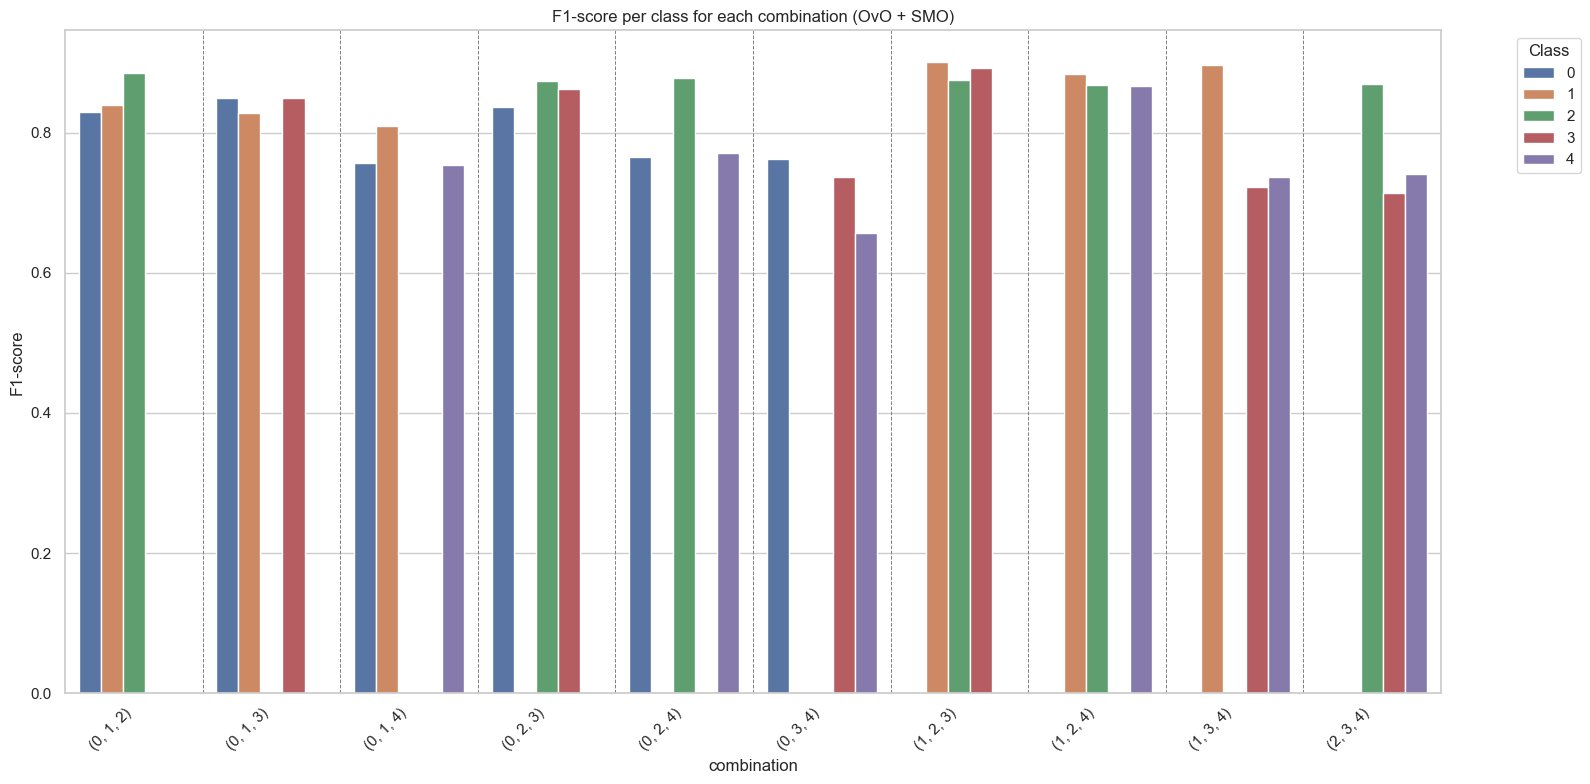

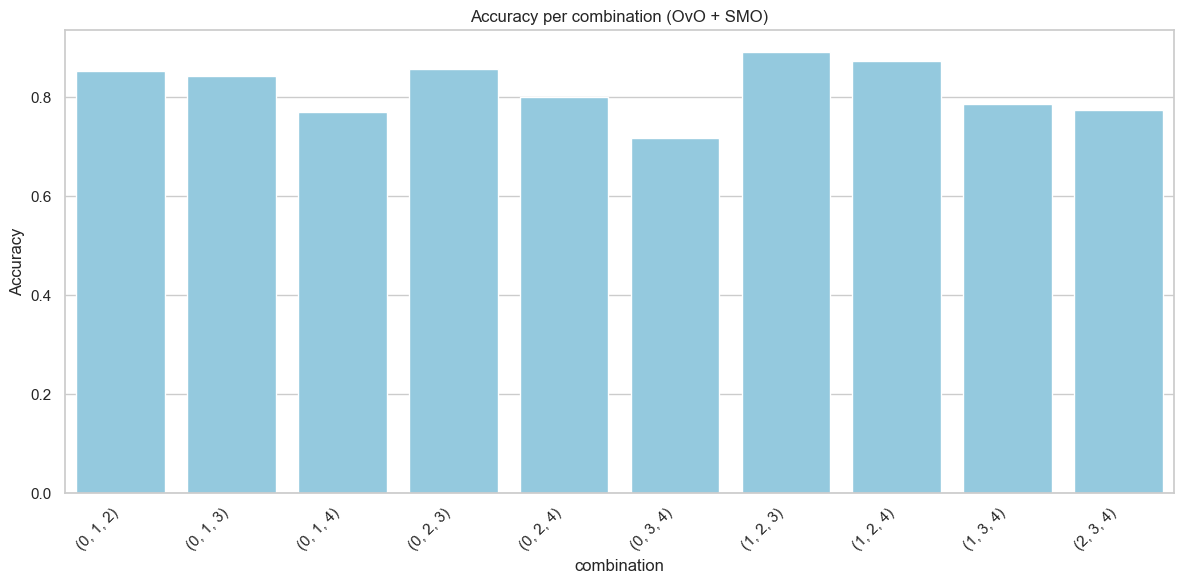

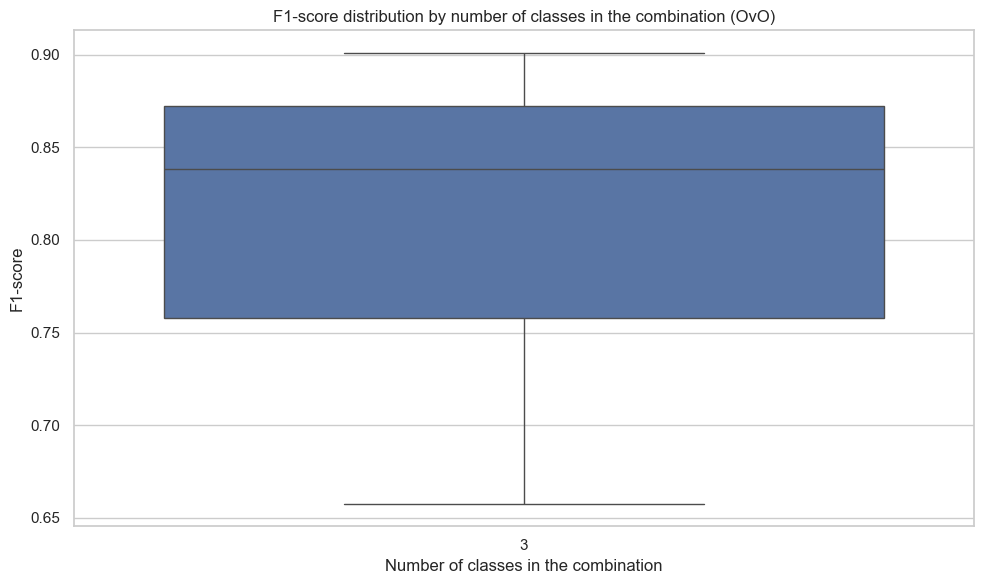

=== PERFORMANCE SUMMARY OvO ===

1. Average performance by number of classes:
               mean       std  count
n_classes                           
3          0.817184  0.067193     30

2. Best combinations by F1-score:
combination  f1-score
  (1, 2, 3)  0.890000
  (1, 2, 4)  0.873333
  (0, 2, 3)  0.856667
  (0, 1, 2)  0.853333
  (0, 1, 3)  0.843333

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.716667
  (0, 1, 4)  0.770000
  (2, 3, 4)  0.773333
  (1, 3, 4)  0.786667
  (0, 2, 4)  0.800000


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_data = []

for result in results_ovo_classic_fit:
    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb)  
        })
    
    # Add overall accuracy
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb)
    })

# Create a DataFrame for plotting
df_plot = pd.DataFrame(plot_data)

# ----------- F1-SCORE PER CLASS PLOT WITH DIVIDER LINES -----------

plt.figure(figsize=(16, 8))

# Filter out 'overall'
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvO + SMO)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Divider lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION PLOT -----------

plt.figure(figsize=(12, 6))
accuracy_data = df_plot[df_plot['class'] == 'overall']

ax = sns.barplot(
    data=accuracy_data,
    x='combination', y='f1-score', 
    color='skyblue'
)
plt.title("Accuracy per combination (OvO + SMO)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of performance grouped by number of classes
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("F1-score distribution by number of classes in the combination (OvO)")
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== PERFORMANCE SUMMARY OvO ===")
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


In [74]:
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import defaultdict

results_ovo_smo_fit = []
all_results_4 = defaultdict(list)

# Grid search lists
C_list = [0.01, 0.05, 0.1]
gamma_list = [0.25, 0.5, 0.75]

for C in C_list:
    for gamma in gamma_list:
        print(f"\n Trying C={C}, gamma={gamma}")

        for comb in possible_combinations:
            print(f"Training on classes: {comb}")
            selected_classes = comb  
            df_temp = df_2[df_2['gt'].isin(selected_classes)]

            X = df_temp.drop('gt', axis=1).values
            y = df_temp['gt'].values

            # Split dataset
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42)

            # Train Multi-class SVM with SMO-based OvO
            multi_svm = MultiSVM(C=C, kernel='Gaussian', gamma=gamma, method='OvO')
            multi_svm.fit_smo(X_train, y_train)
            y_pred = multi_svm.predict(X_test)

            # Classification report and accuracy
            report = classification_report(y_test, y_pred, output_dict=True)
            acc = report['accuracy']
            all_results_4[(C, gamma)].append(acc)

            # Store full result for future use
            results_ovo_smo_fit.append({
                'C': C,
                'gamma': gamma,
                'classes': comb,
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'y_pred': y_pred,
                'report': report
            })

            # Print the report
            print(classification_report(y_test, y_pred))



 Trying C=0.01, gamma=0.25
Training on classes: (0, 1, 2)
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       104
           1       0.88      0.86      0.87        86
           2       0.92      0.85      0.89       110

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

Training on classes: (0, 1, 3)
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       104
           1       0.80      0.86      0.83        86
           3       0.90      0.82      0.86       110

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.85      0.84      0.84       300

Training on classes: (0, 1, 4)
              precision    recall  f1-score   support

           0       0.82      0.64      0.72       104
        

In [75]:
averages = {key: sum(vals) / len(vals) for key, vals in all_results_4.items()}

# Output 
for key, avg in sorted(averages.items()):
    print(f"{key}: {avg:.4f}")

(0.01, 0.25): 0.8093
(0.01, 0.5): 0.8187
(0.01, 0.75): 0.8113
(0.05, 0.25): 0.8097
(0.05, 0.5): 0.8190
(0.05, 0.75): 0.8113
(0.1, 0.25): 0.8037
(0.1, 0.5): 0.8117
(0.1, 0.75): 0.8103


In [29]:
multi_svm = MultiSVM(C=0.05, kernel='Gaussian', gamma=0.5, method='OvO')
time_start = time.time()
multi_svm.fit_smo(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")

Iteration 1, num_changed = 54, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_changed = 0, passes = 1
Iteration 4, num_changed = 0, passes = 2
Iteration 5, num_changed = 0, passes = 3
Iteration 6, num_changed = 0, passes = 4
Iteration 7, num_changed = 0, passes = 5
Iteration 8, num_changed = 0, passes = 6
Iteration 9, num_changed = 0, passes = 7
Iteration 10, num_changed = 0, passes = 8
SMO finished in 10 iterations. Support vectors: 108
Training time: 0.26967668533325195 seconds


In [76]:
selected_C = 0.05
selected_gamma = 0.5

for res in results_ovo_smo_fit:
    if res['C'] == selected_C and res['gamma'] == selected_gamma:
        print("Classes:", res['classes'])
        print("Accuracy:", res['report']['accuracy'])


Classes: (0, 1, 2)
Accuracy: 0.86
Classes: (0, 1, 3)
Accuracy: 0.8333333333333334
Classes: (0, 1, 4)
Accuracy: 0.7966666666666666
Classes: (0, 2, 3)
Accuracy: 0.86
Classes: (0, 2, 4)
Accuracy: 0.7966666666666666
Classes: (0, 3, 4)
Accuracy: 0.7133333333333334
Classes: (1, 2, 3)
Accuracy: 0.8933333333333333
Classes: (1, 2, 4)
Accuracy: 0.87
Classes: (1, 3, 4)
Accuracy: 0.78
Classes: (2, 3, 4)
Accuracy: 0.7866666666666666


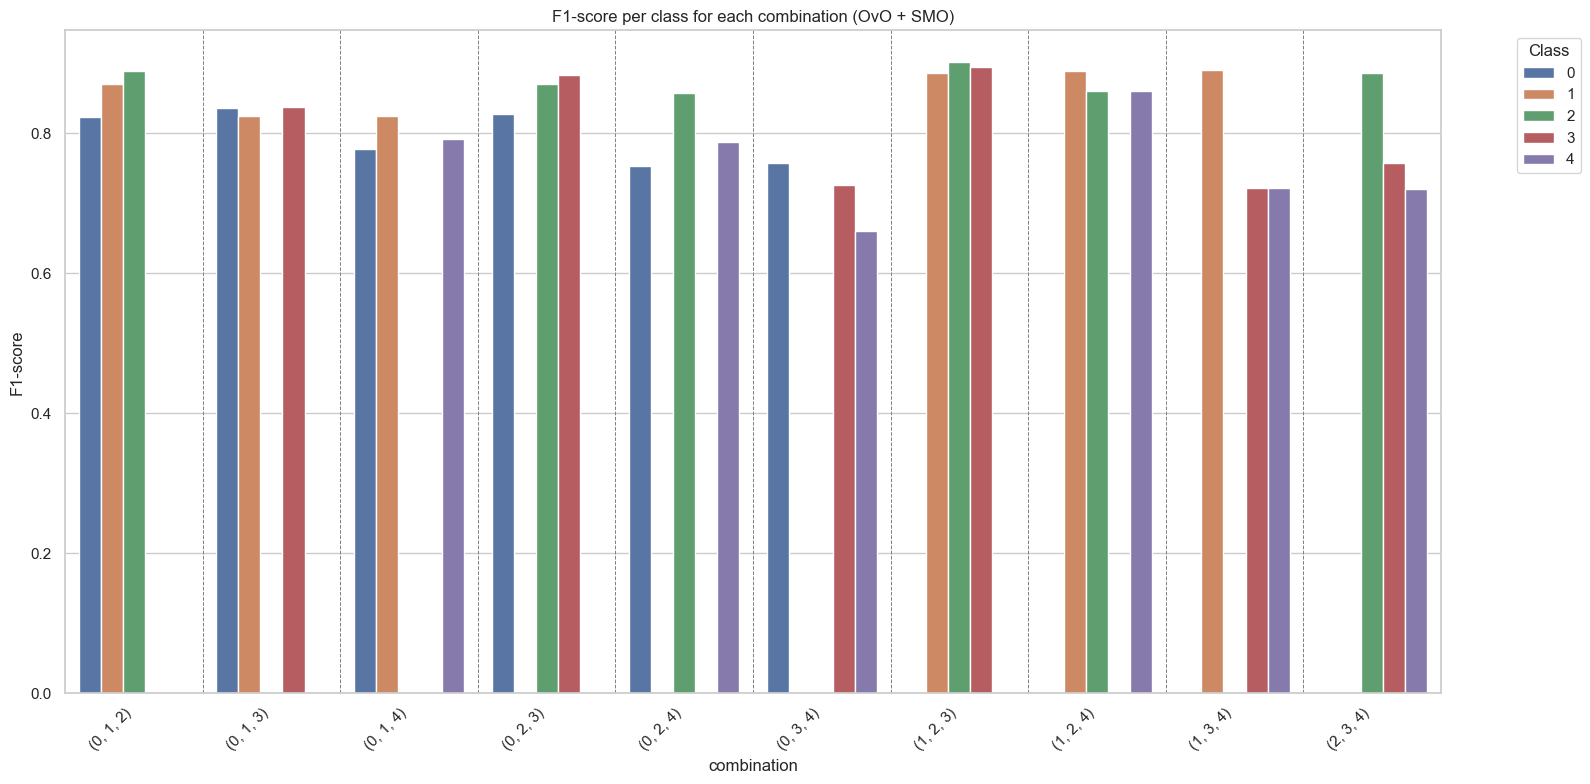

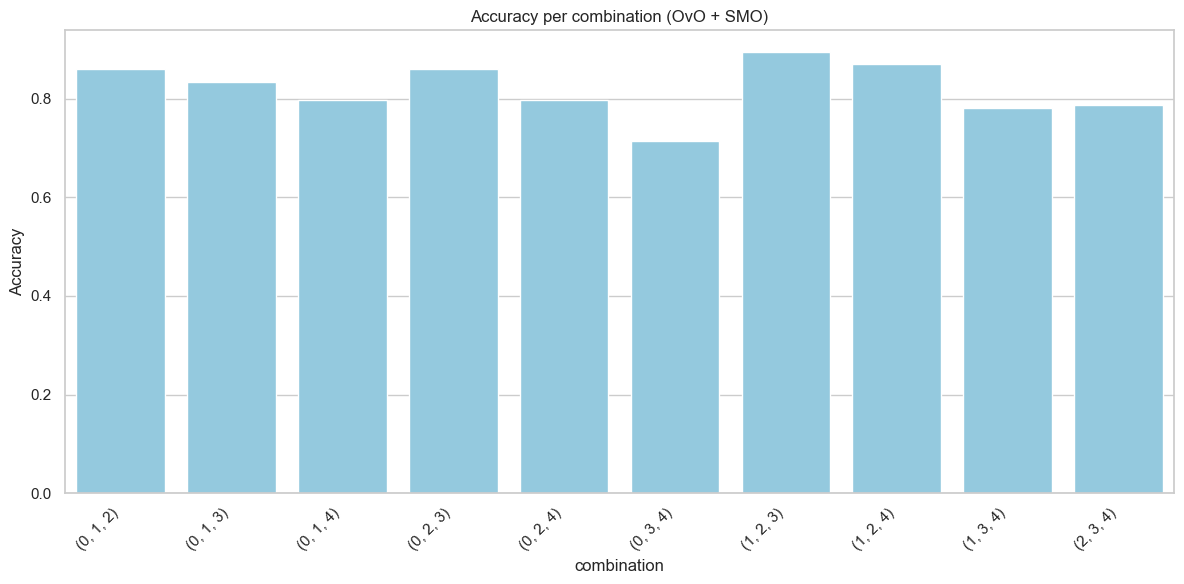

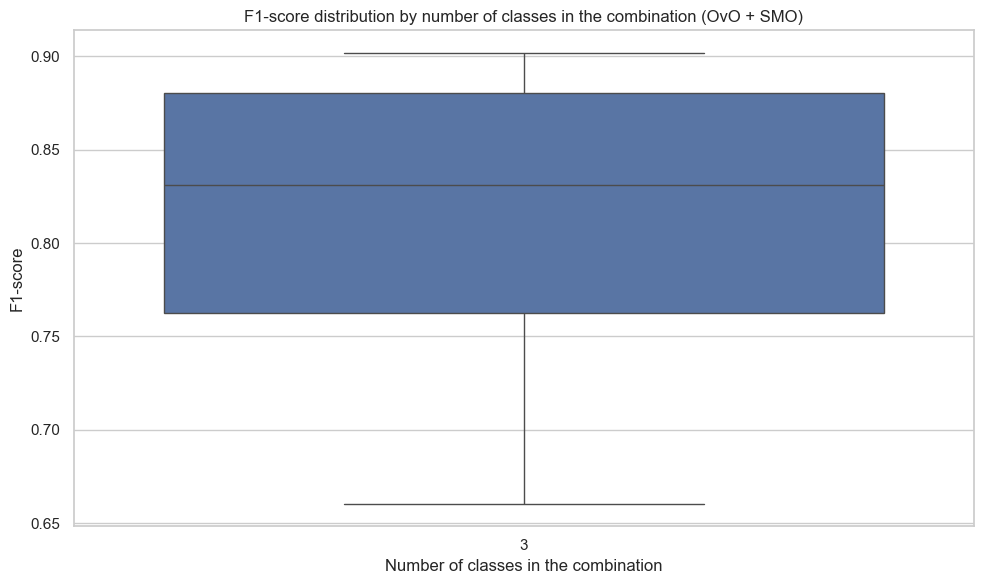

=== PERFORMANCE SUMMARY OvO + SMO ===

1. Average performance by number of classes:
               mean       std  count
n_classes                           
3          0.819384  0.066824     30

2. Best combinations by F1-score:
combination  f1-score
  (1, 2, 3)  0.893333
  (1, 2, 4)  0.870000
  (0, 1, 2)  0.860000
  (0, 2, 3)  0.860000
  (0, 1, 3)  0.833333

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.713333
  (1, 3, 4)  0.780000
  (2, 3, 4)  0.786667
  (0, 1, 4)  0.796667
  (0, 2, 4)  0.796667


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

selected_C = 0.05
selected_gamma = 0.5


plot_data = []

# Filtra SOLO i risultati con C e gamma specificati
for result in results_ovo_smo_fit:
    if result['C'] != selected_C or result['gamma'] != selected_gamma:
        continue  # salta quelli non desiderati

    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb)  
        })
    
    # Add overall accuracy
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb)
    })

# Create DataFrame for plotting
df_plot = pd.DataFrame(plot_data)


# ----------- F1-SCORE PER CLASS PLOT -----------

plt.figure(figsize=(16, 8))

# Filter data to exclude 'overall'
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvO + SMO)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Divider lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION PLOT -----------

plt.figure(figsize=(12, 6))
accuracy_data = df_plot[df_plot['class'] == 'overall']

ax = sns.barplot(
    data=accuracy_data,
    x='combination', y='f1-score', 
    color='skyblue'
)
plt.title("Accuracy per combination (OvO + SMO)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of performance grouped by number of classes
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("F1-score distribution by number of classes in the combination (OvO + SMO)")
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== PERFORMANCE SUMMARY OvO + SMO ===")
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


     pcost       dcost       gap    pres   dres
 0: -1.3986e+02 -1.8226e+03  8e+03  2e+00  8e-16
 1: -1.0394e+02 -1.1045e+03  1e+03  2e-02  6e-16
 2: -1.3347e+02 -2.5629e+02  1e+02  2e-03  7e-16
 3: -1.4623e+02 -1.6905e+02  2e+01  2e-04  3e-16
 4: -1.4937e+02 -1.5504e+02  6e+00  2e-05  3e-16
 5: -1.5012e+02 -1.5196e+02  2e+00  4e-06  3e-16
 6: -1.5038e+02 -1.5098e+02  6e-01  3e-15  3e-16
 7: -1.5047e+02 -1.5056e+02  9e-02  1e-14  3e-16
 8: -1.5049e+02 -1.5049e+02  4e-03  2e-14  3e-16
 9: -1.5049e+02 -1.5049e+02  2e-04  4e-15  3e-16
10: -1.5049e+02 -1.5049e+02  6e-06  2e-15  3e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.3227e+02 -1.5611e+03  6e+03  2e+00  8e-16
 1: -1.0594e+02 -8.8353e+02  8e+02  2e-15  5e-16
 2: -1.3473e+02 -2.3490e+02  1e+02  1e-14  6e-16
 3: -1.4579e+02 -1.6590e+02  2e+01  7e-15  3e-16
 4: -1.4875e+02 -1.5372e+02  5e+00  2e-16  3e-16
 5: -1.4941e+02 -1.5055e+02  1e+00  2e-15  3e-16
 6: -1.4959e+02 -1.4983e+02  2e-01  8e-15  2e-1

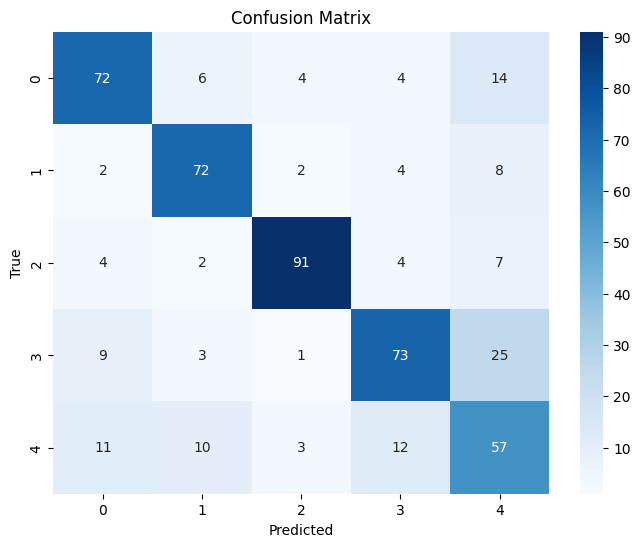

In [30]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvO')
time_start = time.time()
multi_svm.fit(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

     pcost       dcost       gap    pres   dres
 0: -4.0687e+02 -4.3692e+03  2e+04  3e+00  1e-15
 1: -2.8678e+02 -2.5500e+03  3e+03  9e-02  9e-16
 2: -3.2182e+02 -7.8763e+02  5e+02  2e-02  9e-16
 3: -3.5637e+02 -4.7176e+02  1e+02  3e-03  7e-16
 4: -3.6792e+02 -4.0042e+02  3e+01  2e-04  6e-16
 5: -3.7187e+02 -3.8004e+02  8e+00  3e-05  6e-16
 6: -3.7310e+02 -3.7530e+02  2e+00  4e-06  6e-16
 7: -3.7349e+02 -3.7403e+02  5e-01  4e-07  6e-16
 8: -3.7361e+02 -3.7371e+02  1e-01  4e-08  6e-16
 9: -3.7363e+02 -3.7365e+02  2e-02  2e-09  6e-16
10: -3.7363e+02 -3.7364e+02  2e-03  1e-10  6e-16
11: -3.7364e+02 -3.7364e+02  4e-05  3e-12  6e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -2.8027e+02 -4.1386e+03  2e+04  3e+00  1e-15
 1: -1.8652e+02 -2.3322e+03  3e+03  1e-01  9e-16
 2: -2.2310e+02 -6.2803e+02  4e+02  2e-02  9e-16
 3: -2.5315e+02 -3.6094e+02  1e+02  3e-03  7e-16
 4: -2.6400e+02 -2.9094e+02  3e+01  2e-05  7e-16
 5: -2.6723e+02 -2.7403e+02  7e+00  2e-07  7e-1

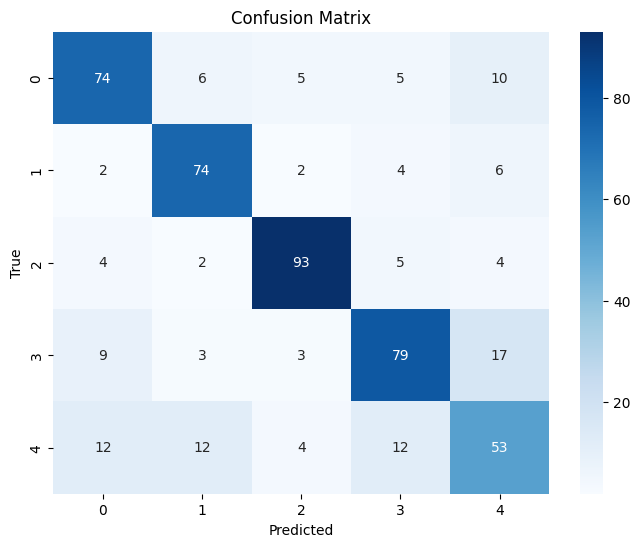

In [31]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvR')
time_start = time.time()
multi_svm.fit(X_train, y_train, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Iteration 1, num_changed = 162, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_changed = 0, passes = 1
Iteration 4, num_changed = 0, passes = 2
Iteration 5, num_changed = 0, passes = 3
Iteration 6, num_changed = 0, passes = 4
Iteration 7, num_changed = 0, passes = 5
Iteration 8, num_changed = 0, passes = 6
Iteration 9, num_changed = 0, passes = 7
Iteration 10, num_changed = 0, passes = 8
Iteration 11, num_changed = 0, passes = 9
Iteration 12, num_changed = 0, passes = 10
Iteration 13, num_changed = 0, passes = 11
Iteration 14, num_changed = 0, passes = 12
Iteration 15, num_changed = 0, passes = 13
Iteration 16, num_changed = 0, passes = 14
Iteration 17, num_changed = 0, passes = 15
Iteration 18, num_changed = 0, passes = 16
Iteration 19, num_changed = 0, passes = 17
Iteration 20, num_changed = 0, passes = 18
SMO finished in 20 iterations. Support vectors: 324
Iteration 1, num_changed = 134, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_chang

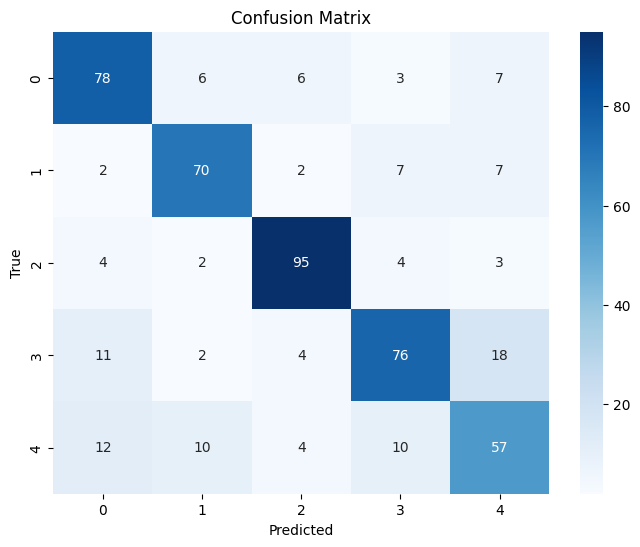

In [32]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=0.05, kernel='Gaussian', gamma=0.5 , method='OvO')
time_start = time.time()
multi_svm.fit_smo(X_train, y_train, max_iter=20, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Iteration 1, num_changed = 67, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_changed = 0, passes = 1
Iteration 4, num_changed = 0, passes = 2
Iteration 5, num_changed = 0, passes = 3
Iteration 6, num_changed = 0, passes = 4
Iteration 7, num_changed = 0, passes = 5
Iteration 8, num_changed = 0, passes = 6
Iteration 9, num_changed = 0, passes = 7
Iteration 10, num_changed = 0, passes = 8
Iteration 11, num_changed = 0, passes = 9
Iteration 12, num_changed = 0, passes = 10
Iteration 13, num_changed = 0, passes = 11
Iteration 14, num_changed = 0, passes = 12
Iteration 15, num_changed = 0, passes = 13
Iteration 16, num_changed = 0, passes = 14
Iteration 17, num_changed = 0, passes = 15
Iteration 18, num_changed = 0, passes = 16
Iteration 19, num_changed = 0, passes = 17
Iteration 20, num_changed = 0, passes = 18
SMO finished in 20 iterations. Support vectors: 134
Iteration 1, num_changed = 131, passes = 0
Iteration 2, num_changed = 0, passes = 0
Iteration 3, num_change

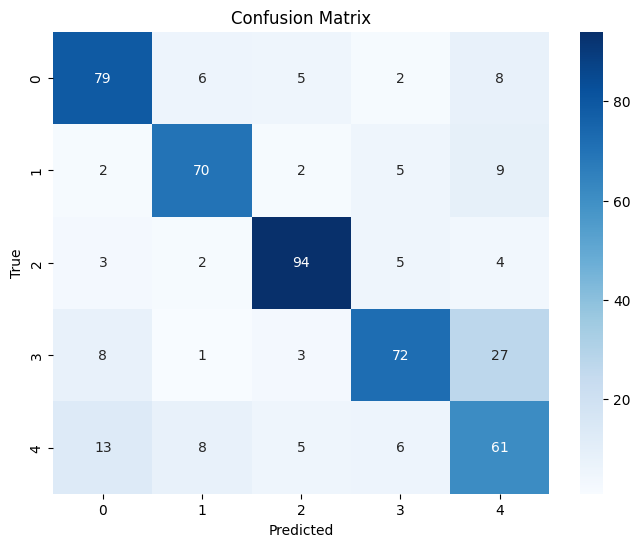

In [33]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=0.05, kernel='Gaussian', gamma=0.5 , method='OvR')
time_start = time.time()
multi_svm.fit_smo(X_train, y_train, max_iter=20, verbose=True)
time_end = time.time()
print(f"Training time: {time_end - time_start} seconds")
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()